In [32]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.table
import astropy.units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord
from crossmatching_3d import Crossmatcher3D
from crossmatching import allowed_angular_separation


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
cm = Crossmatcher3D()
cm.coordinate_search_radius = 25 * u.arcsec
input_table = Table.read("input/HPIC_LC4_combined_d50.txt", format="ascii")
cm.load_catalog(from_file="pscomppars.txt")
cm.load_alternate_ids(input_table[cm.input_starname_key].tolist(), from_file="alternate_ids.txt")
input_table = cm.remove_duplicates(input_table)
print(f"Input: {len(input_table):,} stars | Catalog: {len(cm.catalog_table):,} | IDs: {len(cm.alternate_ids):,} pairs")


Removed Rows with indecies and names: 14453, 7161, 99, 68, 2636, 235, 441
Input: 14,564 stars | Catalog: 6,291 | IDs: 285,054 pairs


3D adds 2 planet(s) (+0.2%)


,ID+3D+2D,ID+2D,Δ
,,,
matched rows,914,912,2
unique planets,853,851,2
id,861,861,0
3d,27,0,27
2d,0,0,0


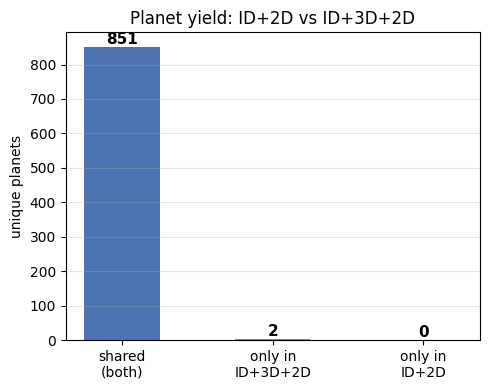

In [34]:
uuid = cm.planet_uid

all_three = cm.combined_crossmatch(input_table)

only_2d_no3d = cm.coords2d_matched[
    ~np.isin(cm.coords2d_matched[uuid].tolist(), cm.id_matched[uuid].tolist())
]
id_plus_2d = astropy.table.vstack([cm.id_matched, only_2d_no3d], join_type="outer")

planets_all3 = set(all_three[uuid].tolist())
planets_id2d = set(id_plus_2d[uuid].tolist())
only_in_all3 = planets_all3 - planets_id2d
only_in_id2d = planets_id2d - planets_all3
in_both      = planets_all3 & planets_id2d
pct_gain = (len(planets_all3) - len(planets_id2d)) / len(planets_id2d) * 100

summary = pd.DataFrame({
    "": ["matched rows", "unique planets", "  id", "  3d", "  2d"],
    "ID+3D+2D": [
        len(all_three), len(planets_all3),
        int(np.sum(all_three["match_type"] == "id")),
        int(np.sum(all_three["match_type"] == "3d")),
        int(np.sum(all_three["match_type"] == "2d")),
    ],
    "ID+2D": [
        len(id_plus_2d), len(planets_id2d),
        int(np.sum(id_plus_2d["match_type"] == "id")),
        0,
        int(np.sum(id_plus_2d["match_type"] == "2d")),
    ],
}).set_index("")
summary["Δ"] = summary["ID+3D+2D"] - summary["ID+2D"]
print(f"3D adds {len(only_in_all3)} planet(s) (+{pct_gain:.1f}%)")
display(summary)

categories = ["shared\n(both)", "only in\nID+3D+2D", "only in\nID+2D"]
values     = [len(in_both), len(only_in_all3), len(only_in_id2d)]
colors     = ["#4C72B0", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(categories, values, color=colors, width=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v),
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel("unique planets")
ax.set_title("Planet yield: ID+2D vs ID+3D+2D")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


In [35]:
extra_planets = sorted(only_in_all3)
excl = all_three[np.isin(all_three[uuid].tolist(), extra_planets)]

cols = excl.colnames
ra_in   = "ra_input"  if "ra_input"  in cols else "ra"
dec_in  = "dec_input" if "dec_input" in cols else "dec"
ra_cat  = "ra_cat"    if "ra_cat"    in cols else "ra"
dec_cat = "dec_cat"   if "dec_cat"   in cols else "dec"

coords_in  = SkyCoord(ra=excl[ra_in]*u.deg,  dec=excl[dec_in]*u.deg)
coords_cat = SkyCoord(ra=excl[ra_cat]*u.deg, dec=excl[dec_cat]*u.deg)
sep_2d = coords_in.separation(coords_cat).to(u.arcsec)

rows = []
for i, row in enumerate(excl):
    rows.append({
        "planet":          str(row[uuid]),
        "input_star":      str(row["star_name"]),
        "nea_host":        str(row["hostname"]),
        "3d_sep [pc]":     round(float(row["3d_sep"]), 4),
        "2d_sep [arcsec]": round(float(sep_2d[i].value), 2),
    })

print(f"Planets found only with 3D matching ({len(rows)}):")
only_3d = Table(rows)
only_3d

Planets found only with 3D matching (2):


planet,input_star,nea_host,3d_sep [pc],2d_sep [arcsec]
str28,str28,str25,float64,float64
CFBDSIR J145829+101343 b,TIC 349714736,CFBDSIR J145829+101343,1.7158,487384.09
2MASS J01033563-5515561 AB b,GAIA DR3 4914126865108605568,2MASS J01033563-5515561 A,2.1861,205464.09


In [36]:
input_table[np.isin(input_table["star_name"],only_3d["input_star"])].pprint_all()

         star_name                sy_dist      st_spectype       st_rad       st_teff      st_mass       st_age        ra            dec           sy_vmag            sy_jmag            sy_hmag            sy_kmag       known_binary_fl gaia_binary_fl WDSsep wds_deltamag
---------------------------- ----------------- ----------- ------------------ ------- ------------------ ------ --------------- ------------- ------------------ ------------------ ------------------ ------------------ --------------- -------------- ------ ------------
               TIC 349714736 24.77140998840332         M2V 0.5370445987169872  3773.0 0.5337591698650853   null 223.72284979897 9.94348147372 10.478222846984863 10.478222846984863 10.478222846984863 10.478222846984863               0              0   null         null
GAIA DR3 4914126865108605568  47.4093017578125        K5.0  0.633057210222462  4314.0 0.6742272039179922   null      20.3255951   -54.5735171 10.677135467529297 10.677135467529297 10.6771354675

In [37]:
pscomppars = Table.read("pscomppars.txt", format="ascii")
pscomppars[np.isin(pscomppars["hostname"],only_3d["nea_host"])].pprint_all()

objectid           pl_name            pl_letter  hostid           hostname         hd_name hip_name     tic_id    disc_pubdate disc_year disc_method discoverymethod disc_locale     disc_facility      disc_instrument           disc_telescope                                                                      disc_refname                                                                  ra            raerr1                raerr2        rasymerr    rastr     ra_solnid                                                               ra_reflink                                                                   dec           decerr1               decerr2        decsymerr     decstr    dec_solnid                                                              dec_reflink                                                                  glon   glonerr1 glonerr2 glonsymerr  glonstr  glon_solnid                                                              glon_reflink                                    

### Why these 3D-exclusive matches are false positives

Both NEA hosts share the same root problem: **no Gaia ID and no proper motion** (`gaia_dr3_id = '--'`, `sy_pm = '--'`). Without a known coordinate epoch, `allowed_angular_separation` falls back to `unknown_default = 50"` for the 2D threshold. The 3D threshold is then dominated by the **distance uncertainty** (`sy_disterr`):

- **CFBDSIR J145829+101343** is a T9 brown dwarf. The NEA carries the original 2011 photometric parallax of 23.1 ± 2.4 pc, so `mean_dist_err ≈ 2.4 pc` → `allowed_3d_sep ≈ 2.40 pc`. The actual 3D separation (1.72 pc) is almost entirely the 1.67 pc distance difference between the HPIC star and the NEA host. Match passes.

- **2MASS J01033563-5515561 A** is a faint young M-dwarf binary with no Gaia. Its large distance uncertainty inflates `allowed_3d_sep ≈ 3.10 pc`. The actual 3D separation (2.19 pc) is dominated by the transverse component: 9489" × 47 pc / 206265 ≈ 2.16 pc. Match passes.

The matched HPIC stars (GJ 3874 M2V, a K5 field star) are **completely unrelated objects** that happen to sit at similar distances. The NEA hosts are faint substellar objects absent from HPIC. The only reason they clear the 3D filter is that missing Gaia data and large photometric distance uncertainties inflate the threshold enough to accommodate a >1° sky offset. **These are false positives.**


In [38]:
coords_in_sweep  = SkyCoord(ra=input_table["ra"]*u.deg, dec=input_table["dec"]*u.deg)
coords_cat_sweep = SkyCoord(ra=cm.catalog_table["ra"]*u.deg, dec=cm.catalog_table["dec"]*u.deg)
idx2d_sweep, sep2d_sweep, _ = coords_cat_sweep.match_to_catalog_sky(coords_in_sweep)

# PM-displacement term per catalog entry (no floor — floor is swept separately)
pm_term = allowed_angular_separation(
    cm.catalog_table["sy_pm"].filled(0) / 1000,
    cm.catalog_table["sy_pmerr1"].filled(0) / 1000,
    cm.catalog_table["coord_epoch"],
    minimum=0 * u.arcsec,
)

cat_planets  = np.array(cm.catalog_table[uuid])
in_names_arr = np.array([str(n) for n in input_table[cm.input_starname_key]])
radii_arcsec = np.linspace(0, 250, 1000)
current_r    = cm.coordinate_search_radius.to(u.arcsec).value

# ── ID oracle ─────────────────────────────────────────────────────────────────
# For each catalog entry i, the coordinate match fires on input star in_names_arr[idx2d_sweep[i]].
# A fired match is a true positive  if that (input_star, planet) pair is also ID-confirmed.
# A fired match is a false positive if the input star has ID matches, but not to this planet.
id_confirmed_pairs = {
    (str(row[cm.input_starname_key]), str(row[uuid]))
    for row in cm.id_matched
}
id_stars = {s for s, _ in id_confirmed_pairs}
id_confirmed_planets = set(str(row[uuid]) for row in cm.id_matched)
n_id_planets = len(id_confirmed_planets)

is_tp = np.array([
    (str(in_names_arr[idx2d_sweep[i]]), str(cat_planets[i])) in id_confirmed_pairs
    for i in range(len(cat_planets))
])
# FP: input star has ID data, but this planet is not among its ID matches
is_fp = np.array([
    str(in_names_arr[idx2d_sweep[i]]) in id_stars and not is_tp[i]
    for i in range(len(cat_planets))
])

print(f"ID oracle: {n_id_planets:,} unique confirmed planets from {len(id_stars):,} input stars")
print(f"Catalog entries:  {is_tp.sum():,} potential TP  |  {is_fp.sum():,} potential FP  |  "
      f"{len(cat_planets) - is_tp.sum() - is_fp.sum():,} unassessable (no ID data for that input star)")


ID oracle: 800 unique confirmed planets from 495 input stars
Catalog entries:  795 potential TP  |  243 potential FP  |  5,253 unassessable (no ID data for that input star)


In [39]:
# ── Precision / Recall sweep ──────────────────────────────────────────────────
def sweep(sep, pm_t):
    """Return (tp, fp, recall, precision) arrays over radii_arcsec."""
    tp  = np.array([len(set(cat_planets[(sep < (pm_t + r*u.arcsec)) & is_tp])) for r in radii_arcsec])
    fp  = np.array([len(set(cat_planets[(sep < (pm_t + r*u.arcsec)) & is_fp])) for r in radii_arcsec])
    rec = tp / n_id_planets
    # Precision over assessable matches only (TP + FP); undefined where both are 0
    prec = np.where(tp + fp > 0, tp / (tp + fp), np.nan)
    return tp, fp, rec, prec

zero_pm = np.zeros(len(cat_planets)) * u.arcsec   # no-epoch: pm_term = 0

tp_pm,  fp_pm,  recall_pm,  prec_pm  = sweep(sep2d_sweep, pm_term)
tp_raw, fp_raw, recall_raw, prec_raw = sweep(sep2d_sweep, zero_pm)

r_idx = np.searchsorted(radii_arcsec, current_r)
print(f"At current floor r = {current_r:.0f}\":")
print(f"  {'':30s}  {'Recall':>8}  {'Precision':>10}  {'TP':>5}  {'FP':>5}")
print(f"  {'With epoch (PM threshold)':<30}  {recall_pm[r_idx]:>8.1%}  {prec_pm[r_idx]:>10.1%}  {tp_pm[r_idx]:>5}  {fp_pm[r_idx]:>5}")
print(f"  {'Fixed radius (no epoch)':<30}  {recall_raw[r_idx]:>8.1%}  {prec_raw[r_idx]:>10.1%}  {tp_raw[r_idx]:>5}  {fp_raw[r_idx]:>5}")


At current floor r = 25":
                                    Recall   Precision     TP     FP
  With epoch (PM threshold)          99.4%      100.0%    795      0
  Fixed radius (no epoch)            95.2%      100.0%    762      0


/tmp/ipykernel_8399/1258833885.py:8: RuntimeWarning: invalid value encountered in divide
  prec = np.where(tp + fp > 0, tp / (tp + fp), np.nan)


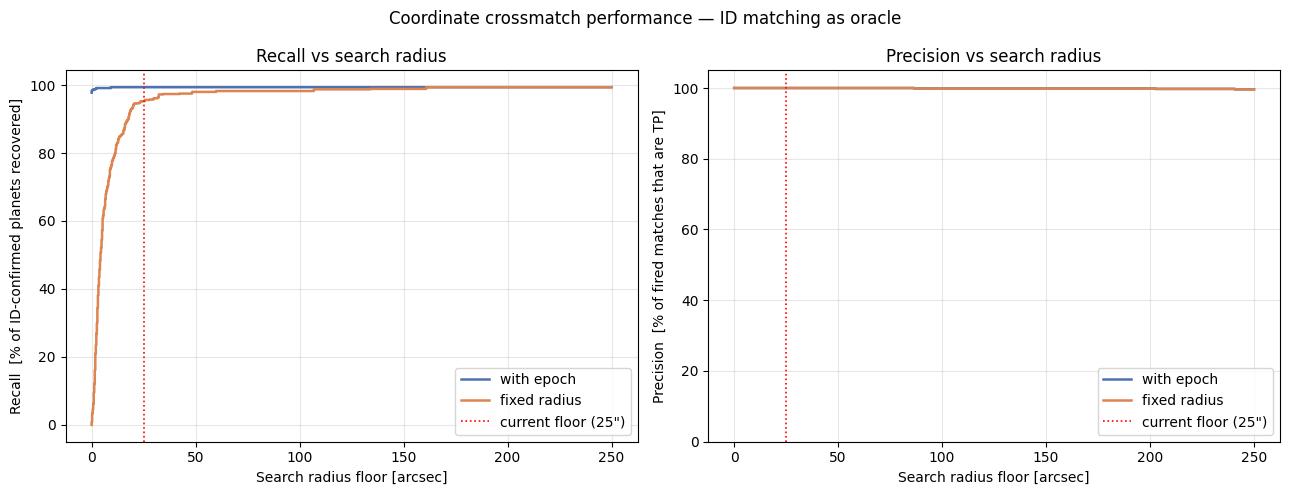

In [40]:
color_epoch = "#4C72B0"
color_raw   = "#DD8452"

fig, (ax_rec, ax_prec) = plt.subplots(1, 2, figsize=(13, 5))

# ── Recall ────────────────────────────────────────────────────────────────────
ax_rec.step(radii_arcsec, recall_pm  * 100, color=color_epoch, lw=1.8, label="with epoch")
ax_rec.step(radii_arcsec, recall_raw * 100, color=color_raw,   lw=1.8, label="fixed radius")
ax_rec.axvline(current_r, color="red", ls=":", lw=1.2, label=f"current floor ({current_r:.0f}\")")
ax_rec.set_xlabel("Search radius floor [arcsec]")
ax_rec.set_ylabel("Recall  [% of ID-confirmed planets recovered]")
ax_rec.set_title("Recall vs search radius")
ax_rec.legend(); ax_rec.grid(True, alpha=0.3)

# ── Precision ─────────────────────────────────────────────────────────────────
ax_prec.step(radii_arcsec, prec_pm  * 100, color=color_epoch, lw=1.8, label="with epoch")
ax_prec.step(radii_arcsec, prec_raw * 100, color=color_raw,   lw=1.8, label="fixed radius")
ax_prec.axvline(current_r, color="red", ls=":", lw=1.2, label=f"current floor ({current_r:.0f}\")")
ax_prec.set_xlabel("Search radius floor [arcsec]")
ax_prec.set_ylabel("Precision  [% of fired matches that are TP]")
ax_prec.set_title("Precision vs search radius")
ax_prec.legend(); ax_prec.grid(True, alpha=0.3)
ax_prec.set_ylim(0, 105)

plt.suptitle("Coordinate crossmatch performance — ID matching as oracle")
plt.tight_layout()
plt.show()


## False-positive estimation: three methods compared

The ID-based FP estimate above only flags matches where the same input star has an *inconsistent* ID match. Two alternative estimates that don't rely on ID matching at all:

**Sky shuffle (Monte Carlo):** Shift all input RA coordinates by a large fixed offset (keeping Dec), re-run coordinate matching — every resulting match is by definition a chance coincidence. Average over 20 offsets (10°–350°).

**Density model (analytic):** For each unique catalog planet, estimate the probability that at least one input star falls within its search cone by chance, given the global input star density. Expected FP count = Σ (1 − e^{−λᵢ}) where λᵢ = π θᵢ² ρ, θᵢ is the search cone radius, and ρ is the input star density on the sky.

In [45]:
# ── Sky shuffle ───────────────────────────────────────────────────────────────
# For each RA offset, re-run the oracle classification (is_tp, is_fp) using
# the shifted nearest-input-star instead of the real one.
# By construction, shifted matches are overwhelmingly FPs — this shows the
# precision floor if matching were random.
n_shuffles = 100
ra_offsets = np.linspace(10, 350, n_shuffles)

shuffle_tp_epoch, shuffle_fp_epoch = [], []
shuffle_tp_raw,   shuffle_fp_raw   = [], []

for offset in ra_offsets:
    shifted = SkyCoord(
        ra  = (input_table["ra"] + offset) % 360 * u.deg,
        dec = input_table["dec"] * u.deg,
    )
    idx_sh, sep_sh, _ = coords_cat_sweep.match_to_catalog_sky(shifted)

    is_tp_sh = np.array([
        (str(in_names_arr[idx_sh[i]]), str(cat_planets[i])) in id_confirmed_pairs
        for i in range(len(cat_planets))
    ])
    is_fp_sh = np.array([
        str(in_names_arr[idx_sh[i]]) in id_stars and not is_tp_sh[i]
        for i in range(len(cat_planets))
    ])

    shuffle_tp_epoch.append([len(set(cat_planets[(sep_sh < (pm_term + r*u.arcsec)) & is_tp_sh])) for r in radii_arcsec])
    shuffle_fp_epoch.append([len(set(cat_planets[(sep_sh < (pm_term + r*u.arcsec)) & is_fp_sh])) for r in radii_arcsec])
    shuffle_tp_raw.append([len(set(cat_planets[(sep_sh < r*u.arcsec) & is_tp_sh])) for r in radii_arcsec])
    shuffle_fp_raw.append([len(set(cat_planets[(sep_sh < r*u.arcsec) & is_fp_sh])) for r in radii_arcsec])

tp_sh_epoch = np.mean(shuffle_tp_epoch, axis=0)
fp_sh_epoch = np.mean(shuffle_fp_epoch, axis=0)
tp_sh_raw   = np.mean(shuffle_tp_raw,   axis=0)
fp_sh_raw   = np.mean(shuffle_fp_raw,   axis=0)

recall_sh_epoch = tp_sh_epoch / n_id_planets
recall_sh_raw   = tp_sh_raw   / n_id_planets
prec_sh_epoch   = np.where(tp_sh_epoch + fp_sh_epoch > 0, tp_sh_epoch / (tp_sh_epoch + fp_sh_epoch), np.nan)
prec_sh_raw     = np.where(tp_sh_raw   + fp_sh_raw   > 0, tp_sh_raw   / (tp_sh_raw   + fp_sh_raw),   np.nan)

print(f"Sky shuffle at r = {current_r:.0f}\"  (mean over {n_shuffles} offsets):")
print(f"  with epoch:   recall = {recall_sh_epoch[r_idx]:.1%},  precision = {prec_sh_epoch[r_idx]:.1%}")
print(f"  fixed radius: recall = {recall_sh_raw[r_idx]:.1%},  precision = {prec_sh_raw[r_idx]:.1%}")


Sky shuffle at r = 25"  (mean over 100 offsets):
  with epoch:   recall = 0.0%,  precision = 0.0%
  fixed radius: recall = 0.0%,  precision = 0.0%


/tmp/ipykernel_8399/3551534724.py:40: RuntimeWarning: invalid value encountered in divide
  prec_sh_epoch   = np.where(tp_sh_epoch + fp_sh_epoch > 0, tp_sh_epoch / (tp_sh_epoch + fp_sh_epoch), np.nan)
/tmp/ipykernel_8399/3551534724.py:41: RuntimeWarning: invalid value encountered in divide
  prec_sh_raw     = np.where(tp_sh_raw   + fp_sh_raw   > 0, tp_sh_raw   / (tp_sh_raw   + fp_sh_raw),   np.nan)


In [42]:
# ── Density model ─────────────────────────────────────────────────────────────
sky_area_arcsec2 = 4 * np.pi * (180 * 3600 / np.pi) ** 2
rho_input = len(input_table) / sky_area_arcsec2

pm_term_arcsec = pm_term.to(u.arcsec).value
planet_str     = np.array([str(p) for p in cat_planets])
unique_planets = np.unique(planet_str)
planet_pm      = np.array([pm_term_arcsec[planet_str == p][0] for p in unique_planets])

# Expected chance-coincidence FP count: Σᵢ (1 − exp(−λᵢ)),  λᵢ = π θᵢ² ρ
density_fp_epoch = np.array([
    np.sum(1 - np.exp(-np.pi * (planet_pm + r) ** 2 * rho_input))
    for r in radii_arcsec
])
density_fp_raw = np.array([
    len(unique_planets) * (1 - np.exp(-np.pi * r ** 2 * rho_input))
    for r in radii_arcsec
])

# Implied precision: use actual TP from real matching, but density-model FP estimate
prec_density_epoch = np.where(
    tp_pm + density_fp_epoch > 0,
    tp_pm / (tp_pm + density_fp_epoch), np.nan
)
prec_density_raw = np.where(
    tp_raw + density_fp_raw > 0,
    tp_raw / (tp_raw + density_fp_raw), np.nan
)

print(f"Density model at r = {current_r:.0f}\":")
print(f"  with epoch:   density FP = {density_fp_epoch[r_idx]:.1f},  implied precision = {prec_density_epoch[r_idx]:.1%}")
print(f"  fixed radius: density FP = {density_fp_raw[r_idx]:.1f},  implied precision = {prec_density_raw[r_idx]:.1%}")
print(f"\nρ_input = {rho_input:.2e} stars/arcsec²  |  {len(unique_planets):,} unique catalog planets")


Density model at r = 25":
  with epoch:   density FP = 0.4,  implied precision = 99.9%
  fixed radius: density FP = 0.3,  implied precision = 100.0%

ρ_input = 2.72e-08 stars/arcsec²  |  6,291 unique catalog planets


/tmp/ipykernel_8399/286605882.py:27: RuntimeWarning: invalid value encountered in divide
  tp_raw / (tp_raw + density_fp_raw), np.nan


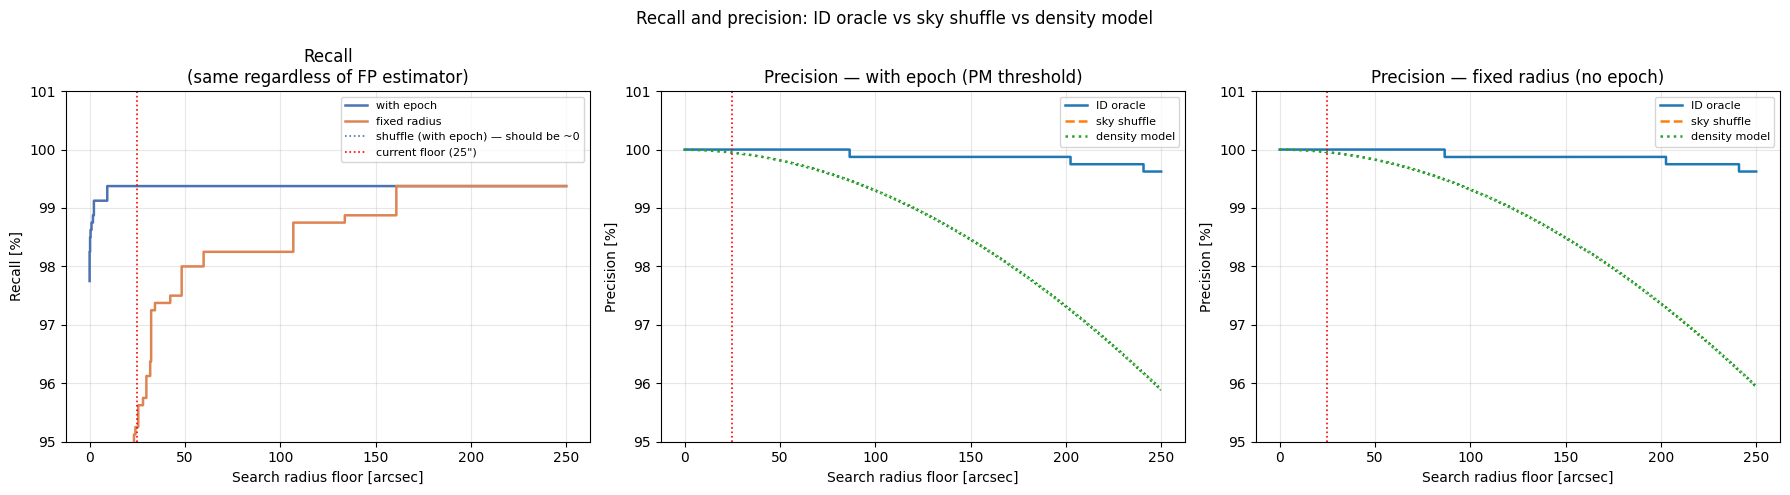

In [52]:
# Recall is identical across FP estimation methods (depends only on TP, not FP).
# Precision differs: each method implies a different FP rate.
# Left panels: recall (epoch vs fixed).  Right panels: precision per FP method.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Recall ────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.step(radii_arcsec, recall_pm  * 100, lw=1.8, color="#4C72B0", label="with epoch")
ax.step(radii_arcsec, recall_raw * 100, lw=1.8, color="#DD8452", label="fixed radius")
ax.step(radii_arcsec, recall_sh_epoch * 100, lw=1.2, color="#4C72B0", ls=":",
        label="shuffle (with epoch) — should be ~0")
ax.axvline(current_r, color="red", ls=":", lw=1.2, label=f"current floor ({current_r:.0f}\")")
ax.set_xlabel("Search radius floor [arcsec]")
ax.set_ylabel("Recall [%]")
ax.set_title("Recall\n(same regardless of FP estimator)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Precision: with epoch ─────────────────────────────────────────────────────
ax = axes[1]
ax.step(radii_arcsec, prec_pm           * 100, lw=1.8,       label="ID oracle")
ax.step(radii_arcsec, prec_sh_epoch     * 100, lw=1.8, ls="--", label="sky shuffle")
ax.step(radii_arcsec, prec_density_epoch* 100, lw=1.8, ls=":",  label="density model")
ax.axvline(current_r, color="red", ls=":", lw=1.2)
ax.set_xlabel("Search radius floor [arcsec]")
ax.set_ylabel("Precision [%]")
ax.set_title("Precision — with epoch (PM threshold)")
ax.set_ylim(0, 105)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Precision: fixed radius ───────────────────────────────────────────────────
ax = axes[2]
ax.step(radii_arcsec, prec_raw          * 100, lw=1.8,       label="ID oracle")
ax.step(radii_arcsec, prec_sh_raw       * 100, lw=1.8, ls="--", label="sky shuffle")
ax.step(radii_arcsec, prec_density_raw  * 100, lw=1.8, ls=":",  label="density model")
ax.axvline(current_r, color="red", ls=":", lw=1.2)
ax.set_xlabel("Search radius floor [arcsec]")
ax.set_ylabel("Precision [%]")
ax.set_title("Precision — fixed radius (no epoch)")
ax.set_ylim(0, 105)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)


axes[0].set_ylim(95, 101)
axes[1].set_ylim(95, 101)
axes[2].set_ylim(95, 101)
plt.suptitle("Recall and precision: ID oracle vs sky shuffle vs density model")
plt.tight_layout()
plt.show()


## Position-corrected matching vs radius-inflated matching

Instead of adding the full PM displacement to the search radius, propagate each catalog star's position forward (or backward) to the HPIC reference epoch (J2000) using measured `sy_pmra`/`sy_pmdec`, then use only the **PM error** vector (`sy_pmraerr1`, `sy_pmdecerr1`) as the search radius contribution.

- **Current**: position unchanged, radius = (pm + pm_err) × |Δt| + floor  
- **Corrected**: position shifted by pm × Δt, radius = pm_err × |Δt| + floor

The radius shrinks by the full PM displacement term. For fast-moving stars the effect is dramatic; for most stars with small PM it will be minor.

Median threshold at r = 25"  (known-epoch entries only):
  inflate radius : 25.3 arcsec
  correct + pmerr: 25.0 arcsec  (1.0× tighter)

At r = 25":
  Method                            Recall   Precision     TP     FP
  Inflate radius                     99.4%      100.0%    795      0
  Correct position + pmerr           99.4%      100.0%    795      0


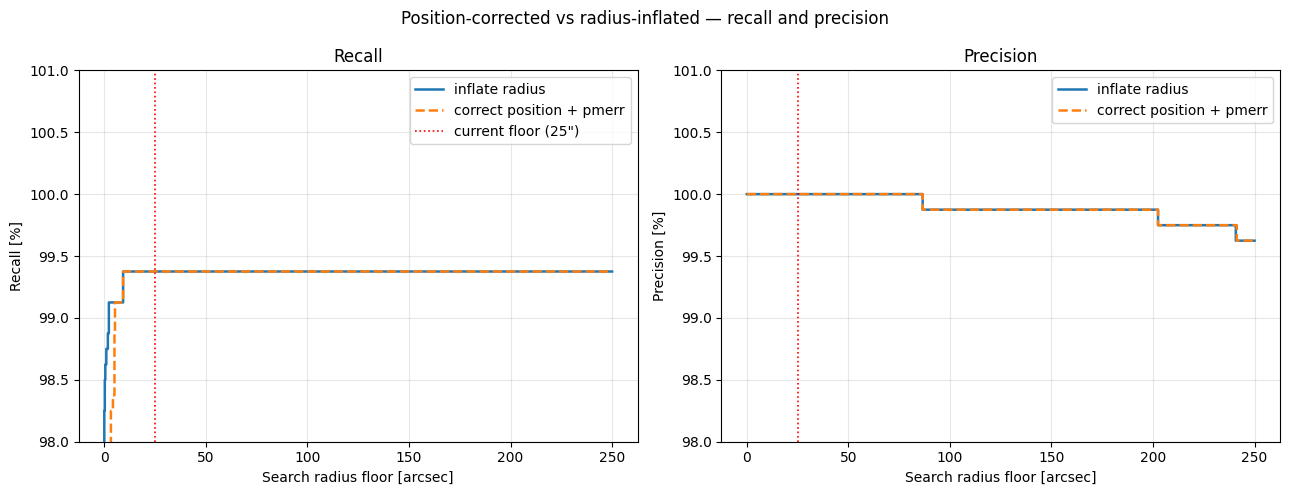

In [54]:
from astropy.time import Time

cat = cm.catalog_table

# ── Propagate positions to J2000 ──────────────────────────────────────────────
epochs_filled = np.ma.filled(cat["coord_epoch"].data, 2000.0)
epoch_unknown = np.ma.getmaskarray(cat["coord_epoch"])

pmra_filled  = np.ma.filled(cat["sy_pmra"],  0.0).copy()
pmdec_filled = np.ma.filled(cat["sy_pmdec"], 0.0).copy()
pmra_filled[epoch_unknown]  = 0.0
pmdec_filled[epoch_unknown] = 0.0

cat_with_pm = SkyCoord(
    ra=cat["ra"].data * u.deg,
    dec=cat["dec"].data * u.deg,
    pm_ra_cosdec=pmra_filled  * u.mas/u.yr,
    pm_dec       =pmdec_filled * u.mas/u.yr,
    obstime=Time(epochs_filled, format="jyear"),
    frame="icrs",
)
cat_at_2000 = cat_with_pm.apply_space_motion(new_obstime=Time(2000.0, format="jyear"))
_, sep_corr, _ = cat_at_2000.match_to_catalog_sky(coords_in_sweep)

# ── Error-only search radius ───────────────────────────────────────────────────
pmra_err   = np.ma.filled(cat["sy_pmraerr1"],  np.nan)
pmdec_err  = np.ma.filled(cat["sy_pmdecerr1"], np.nan)
pm_vec_err = np.sqrt(pmra_err**2 + pmdec_err**2)
dt = np.abs(epochs_filled - 2000.0)
pmerr_radius_arcsec = pm_vec_err * dt / 1000
pmerr_radius_arcsec = np.where(
    epoch_unknown | np.isnan(pmerr_radius_arcsec), 50.0, pmerr_radius_arcsec
)
pmerr_thresh = pmerr_radius_arcsec * u.arcsec

old_thresh = (pm_term + current_r * u.arcsec).to(u.arcsec).value
new_thresh  = pmerr_radius_arcsec + current_r
has_epoch   = ~epoch_unknown
print(f"Median threshold at r = {current_r:.0f}\"  (known-epoch entries only):")
print(f"  inflate radius : {np.median(old_thresh[has_epoch]):.1f} arcsec")
print(f"  correct + pmerr: {np.median(new_thresh[has_epoch]):.1f} arcsec  "
      f"({np.nanmedian(old_thresh[has_epoch] / new_thresh[has_epoch]):.1f}× tighter)")

# ── Sweep with oracle ─────────────────────────────────────────────────────────
tp_corr, fp_corr, recall_corr, prec_corr = sweep(sep_corr, pmerr_thresh)

r_idx = np.searchsorted(radii_arcsec, current_r)
print(f"\nAt r = {current_r:.0f}\":")
print(f"  {'Method':<30}  {'Recall':>8}  {'Precision':>10}  {'TP':>5}  {'FP':>5}")
print(f"  {'Inflate radius':<30}  {recall_pm[r_idx]:>8.1%}  {prec_pm[r_idx]:>10.1%}  {tp_pm[r_idx]:>5}  {fp_pm[r_idx]:>5}")
print(f"  {'Correct position + pmerr':<30}  {recall_corr[r_idx]:>8.1%}  {prec_corr[r_idx]:>10.1%}  {tp_corr[r_idx]:>5}  {fp_corr[r_idx]:>5}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.step(radii_arcsec, recall_pm   * 100, lw=1.8, label="inflate radius")
ax1.step(radii_arcsec, recall_corr * 100, lw=1.8, label="correct position + pmerr", ls="--")
ax1.axvline(current_r, color="red", ls=":", lw=1.2, label=f"current floor ({current_r:.0f}\")")
ax1.set_xlabel("Search radius floor [arcsec]"); ax1.set_ylabel("Recall [%]")
ax1.set_title("Recall"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_ylim(98, 101)

ax2.step(radii_arcsec, prec_pm   * 100, lw=1.8, label="inflate radius")
ax2.step(radii_arcsec, prec_corr * 100, lw=1.8, label="correct position + pmerr", ls="--")
ax2.axvline(current_r, color="red", ls=":", lw=1.2)
ax2.set_xlabel("Search radius floor [arcsec]"); ax2.set_ylabel("Precision [%]")
ax2.set_title("Precision"); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(98, 101)


plt.suptitle("Position-corrected vs radius-inflated — recall and precision")
plt.tight_layout(); plt.show()
